# 5. Predictive modelling: Machine Learning

Baseline protocol-specific models for:
 - high_glucose
 - metabolic_syndrome

Design choices:
 - keep the analysis protocol-specific
 - compare simple feature blocks
 - compare one linear baseline and one non-linear baseline
 - keep the code compact and reproducible

In [238]:
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

## 5.1. Working table and feature blocks

In [239]:
model_df = stat_analysis_df.copy()

# Main targets to evaluate
MODEL_TARGETS = [
    "high_glucose",
    "metabolic_syndrome",
]
MODEL_TARGETS = [c for c in MODEL_TARGETS if c in model_df.columns]

In [240]:
# Feature blocks
FEATURE_BLOCKS = {
    "physics": [
        "c700",
        "visc",
        "c700_sd",
        "visc_sd",
    ],
    "signal": [
        "p2p_median",
        "rms_median",
        "drift_ratio_median",
        "roughness_ratio_median",
    ],
    "combined": [
        "c700",
        "visc",
        "c700_sd",
        "visc_sd",
        "p2p_median",
        "rms_median",
        "drift_ratio_median",
        "roughness_ratio_median",
    ],
}

In [241]:
# Keep only columns that actually exist
FEATURE_BLOCKS = {
    block_name: [c for c in cols if c in model_df.columns]
    for block_name, cols in FEATURE_BLOCKS.items()
}
FEATURE_BLOCKS = {
    block_name: cols
    for block_name, cols in FEATURE_BLOCKS.items()
    if len(cols) >= 2
}

In [242]:
# Make relevant columns numeric
for col in set(sum(FEATURE_BLOCKS.values(), []) + MODEL_TARGETS):
    if col in model_df.columns:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

print("\nFeature blocks used for modelling")
display(
    pd.DataFrame({
        "feature_block": list(FEATURE_BLOCKS.keys()),
        "n_features": [len(v) for v in FEATURE_BLOCKS.values()],
        "features": [", ".join(v) for v in FEATURE_BLOCKS.values()],
    })
)



Feature blocks used for modelling


,feature_block,n_features,features
0,physics,4,"c700, visc, c700_sd, visc_sd"
1,signal,4,"p2p_median, rms_median, drift_ratio_median, ro..."
2,combined,8,"c700, visc, c700_sd, visc_sd, p2p_median, rms_..."


## 5.2. Baseline model definitions

In [243]:
MODEL_SPECS = {
    "logreg": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42,
        )),
    ]),
    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
        )),
    ]),
}

## 5.3. Cross-validated evaluation helper

In [244]:
def _evaluate_baseline_model(df, protocol_value, target_col, feature_block_name, feature_cols, model_name, model_obj):
    """
    Evaluate one model with one feature block inside one protocol.

    The function is intentionally conservative:
    - protocol-specific only
    - requires both classes to be present
    - requires a minimum number of positive cases
    """
    tmp = df.loc[df["protocol_version"] == protocol_value].copy()

    # Keep only target rows that are known
    tmp = tmp.loc[tmp[target_col].notna()].copy()
    if tmp.empty:
        return None

    # Keep only features that have at least one observed value in this protocol
    available_feature_cols = [c for c in feature_cols if tmp[c].notna().sum() > 0]
    if len(available_feature_cols) < 2:
        return None

    X = tmp[available_feature_cols].copy()
    y = tmp[target_col].astype(int).copy()

    # Require both classes to be present
    class_counts = y.value_counts(dropna=False)
    if len(class_counts) < 2:
        return None

    # Require a minimum amount of minority-class data
    min_class_n = int(class_counts.min())
    if min_class_n < 10 or len(tmp) < 50:
        return None

    # Use as many folds as safely allowed, up to 5
    n_splits = min(5, min_class_n)
    if n_splits < 3:
        return None

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42,
    )

    scores = cross_validate(
        model_obj,
        X,
        y,
        cv=cv,
        scoring={
            "roc_auc": "roc_auc",
            "balanced_accuracy": "balanced_accuracy",
        },
        error_score="raise",
    )

    return {
        "protocol_version": protocol_value,
        "target": target_col,
        "feature_block": feature_block_name,
        "model": model_name,
        "n_units": int(len(tmp)),
        "n_positive": int((y == 1).sum()),
        "positive_prevalence_pct": 100 * float((y == 1).mean()),
        "n_features_used": int(len(available_feature_cols)),
        "features_used": ", ".join(available_feature_cols),
        "n_splits": int(n_splits),
        "mean_roc_auc": float(np.mean(scores["test_roc_auc"])),
        "sd_roc_auc": float(np.std(scores["test_roc_auc"])),
        "mean_balanced_accuracy": float(np.mean(scores["test_balanced_accuracy"])),
        "sd_balanced_accuracy": float(np.std(scores["test_balanced_accuracy"])),
    }

## 5.4. Run the baseline comparison

In [245]:
baseline_rows = []

protocol_list = sorted(model_df["protocol_version"].dropna().unique())

for protocol_value in protocol_list:
    for target_col in MODEL_TARGETS:
        for feature_block_name, feature_cols in FEATURE_BLOCKS.items():
            for model_name, model_obj in MODEL_SPECS.items():
                row = _evaluate_baseline_model(
                    df=model_df,
                    protocol_value=protocol_value,
                    target_col=target_col,
                    feature_block_name=feature_block_name,
                    feature_cols=feature_cols,
                    model_name=model_name,
                    model_obj=model_obj,
                )

                if row is not None:
                    baseline_rows.append(row)

baseline_results_df = pd.DataFrame(baseline_rows)

if not baseline_results_df.empty:
    baseline_results_df = baseline_results_df.sort_values(
        ["target", "protocol_version", "mean_roc_auc"],
        ascending=[True, True, False],
    ).reset_index(drop=True)

print("\nBaseline modelling results")
display(baseline_results_df)


Baseline modelling results


,protocol_version,target,feature_block,model,n_units,n_positive,positive_prevalence_pct,n_features_used,features_used,n_splits,mean_roc_auc,sd_roc_auc,mean_balanced_accuracy,sd_balanced_accuracy
0,new,high_glucose,physics,random_forest,258,27,10.465116,4,"c700, visc, c700_sd, visc_sd",5,0.653919,0.080314,0.545409,0.092977
1,new,high_glucose,physics,logreg,258,27,10.465116,4,"c700, visc, c700_sd, visc_sd",5,0.641980,0.155276,0.634132,0.114172
2,new,high_glucose,combined,random_forest,258,27,10.465116,8,"c700, visc, c700_sd, visc_sd, p2p_median, rms_...",5,0.639208,0.101697,0.492754,0.048664
3,new,high_glucose,combined,logreg,258,27,10.465116,8,"c700, visc, c700_sd, visc_sd, p2p_median, rms_...",5,0.634095,0.113994,0.558264,0.081735
4,new,high_glucose,signal,random_forest,258,27,10.465116,4,"p2p_median, rms_median, drift_ratio_median, ro...",5,0.604665,0.159551,0.500515,0.051586
5,new,high_glucose,signal,logreg,258,27,10.465116,4,"p2p_median, rms_median, drift_ratio_median, ro...",5,0.589704,0.080827,0.567296,0.092027
6,old,high_glucose,signal,logreg,470,80,17.021277,4,"p2p_median, rms_median, drift_ratio_median, ro...",5,0.598878,0.033668,0.579647,0.029119
7,old,high_glucose,signal,random_forest,470,80,17.021277,4,"p2p_median, rms_median, drift_ratio_median, ro...",5,0.586218,0.035215,0.517468,0.024751
8,old,high_glucose,combined,logreg,470,80,17.021277,8,"c700, visc, c700_sd, visc_sd, p2p_median, rms_...",5,0.570192,0.043410,0.550962,0.027128
9,old,high_glucose,combined,random_forest,470,80,17.021277,8,"c700, visc, c700_sd, visc_sd, p2p_median, rms_...",5,0.519712,0.107567,0.511538,0.026938


## 5.5. Best baseline per protocol and target

In [246]:
best_baseline_df = pd.DataFrame()

if not baseline_results_df.empty:
    best_baseline_df = (
        baseline_results_df
        .sort_values(
            ["target", "protocol_version", "mean_roc_auc", "mean_balanced_accuracy"],
            ascending=[True, True, False, False],
        )
        .groupby(["target", "protocol_version"], as_index=False)
        .first()
        .sort_values(["target", "protocol_version"])
        .reset_index(drop=True)
    )

print("\nBest baseline per protocol and target")
display(best_baseline_df)


Best baseline per protocol and target


,target,protocol_version,feature_block,model,n_units,n_positive,positive_prevalence_pct,n_features_used,features_used,n_splits,mean_roc_auc,sd_roc_auc,mean_balanced_accuracy,sd_balanced_accuracy
0,high_glucose,new,physics,random_forest,258,27,10.465116,4,"c700, visc, c700_sd, visc_sd",5,0.653919,0.080314,0.545409,0.092977
1,high_glucose,old,signal,logreg,470,80,17.021277,4,"p2p_median, rms_median, drift_ratio_median, ro...",5,0.598878,0.033668,0.579647,0.029119
2,metabolic_syndrome,new,physics,random_forest,258,63,24.418605,4,"c700, visc, c700_sd, visc_sd",5,0.534057,0.063602,0.519231,0.025237
3,metabolic_syndrome,old,signal,logreg,470,93,19.787234,4,"p2p_median, rms_median, drift_ratio_median, ro...",5,0.574942,0.077652,0.551392,0.060521


## 5.6. Compact visual summaries

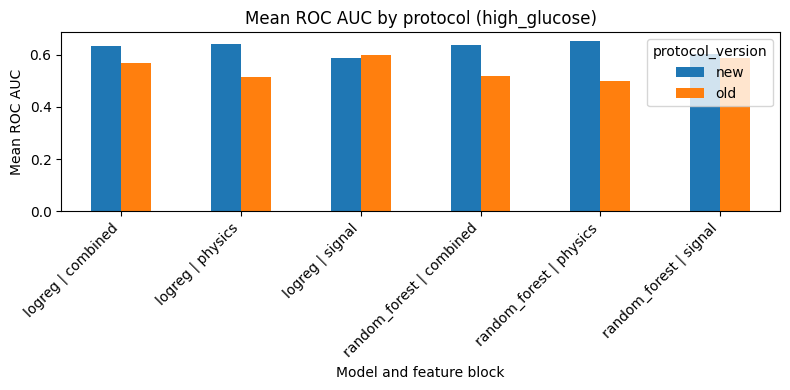

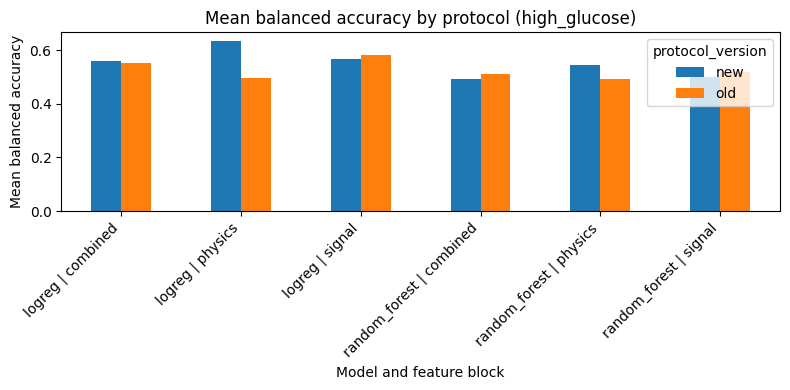

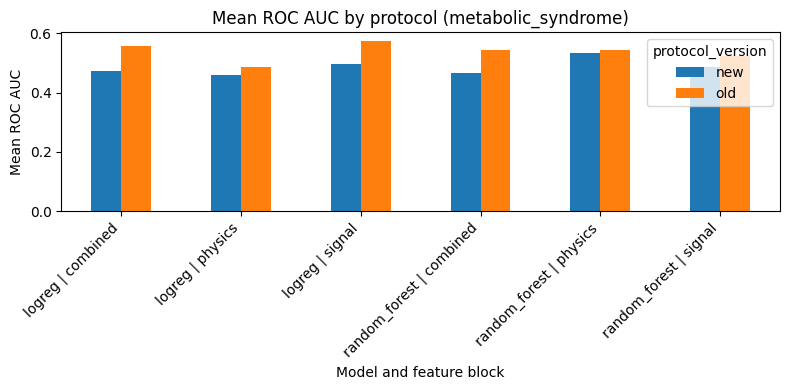

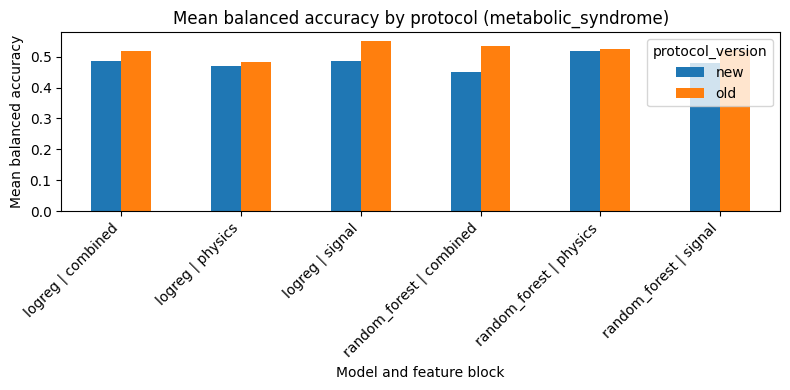

In [247]:
if not baseline_results_df.empty:
    baseline_plot_df = baseline_results_df.copy()
    baseline_plot_df["model_block"] = (
        baseline_plot_df["model"] + " | " + baseline_plot_df["feature_block"]
    )

    for target_col in sorted(baseline_plot_df["target"].dropna().unique()):
        target_df = baseline_plot_df.loc[
            baseline_plot_df["target"] == target_col
        ].copy()

        if target_df.empty:
            continue

        # Mean ROC AUC
        roc_plot_df = target_df.pivot(
            index="model_block",
            columns="protocol_version",
            values="mean_roc_auc",
        )

        ax = roc_plot_df.plot(kind="bar", figsize=(8, 4))
        ax.set_title(f"Mean ROC AUC by protocol ({target_col})")
        ax.set_xlabel("Model and feature block")
        ax.set_ylabel("Mean ROC AUC")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

        # Mean balanced accuracy
        ba_plot_df = target_df.pivot(
            index="model_block",
            columns="protocol_version",
            values="mean_balanced_accuracy",
        )

        ax = ba_plot_df.plot(kind="bar", figsize=(8, 4))
        ax.set_title(f"Mean balanced accuracy by protocol ({target_col})")
        ax.set_xlabel("Model and feature block")
        ax.set_ylabel("Mean balanced accuracy")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

## 5.7. Targeted modelling of high_glucose using protocol-specific site-frequency features

### 5.7.1. Configuration

In [248]:
TARGET_COL = "high_glucose"

# Candidate protocol/site/frequency combinations selected
# from the exploratory frequency-wise analysis
TARGETED_CONFIG = {
    "old": {
        "A": [600, 800, 1000],
        "P": [600, 800, 1000],
    },
    "new": {
        "B": [600, 800, 1000],
        "P": [400, 600],
    },
}

UNIT_KEYS = [
    "global_patient_id",
    "hospital_patient_id",
    "protocol_version",
    "timepoint",
    "site_code",
]

### 5.7.2. Build a targeted frequency-level table

In [249]:
def _build_targeted_frequency_rows(df, targeted_config):
    """
    Create one row per retained acquisition x selected frequency.
    Only selected protocol/site/frequency combinations are kept.
    """
    rows = []

    use_cols = [
        "signal_record_id",
        "global_patient_id",
        "hospital_patient_id",
        "protocol_version",
        "timepoint",
        "site_code",
        "high_glucose",
        "freq_to_array",
    ]
    use_cols = [c for c in use_cols if c in df.columns]

    for row in df[use_cols].itertuples(index=False):
        if not isinstance(row.freq_to_array, dict):
            continue

        protocol_value = row.protocol_version
        site_code = row.site_code

        if protocol_value not in targeted_config:
            continue
        if site_code not in targeted_config[protocol_value]:
            continue

        selected_freqs = targeted_config[protocol_value][site_code]

        for frequency_hz in selected_freqs:
            if frequency_hz not in row.freq_to_array:
                continue

            arr = np.asarray(row.freq_to_array[frequency_hz], dtype=float)
            if arr.size == 0:
                continue

            rows.append({
                "signal_record_id": row.signal_record_id,
                "global_patient_id": row.global_patient_id,
                "hospital_patient_id": row.hospital_patient_id,
                "protocol_version": protocol_value,
                "timepoint": row.timepoint,
                "site_code": site_code,
                "frequency_hz": int(frequency_hz),
                "high_glucose": row.high_glucose,
                "p2p_freq": float(np.ptp(arr)),
                "rms_freq": float(np.sqrt(np.mean(arr ** 2))),
            })

    return pd.DataFrame(rows)

In [250]:
targeted_freq_rows_df = _build_targeted_frequency_rows(
    stat_base_df,
    targeted_config=TARGETED_CONFIG,
)

print("\nTargeted frequency-level rows")
display(targeted_freq_rows_df.head())


Targeted frequency-level rows


,signal_record_id,global_patient_id,hospital_patient_id,protocol_version,timepoint,site_code,frequency_hz,high_glucose,p2p_freq,rms_freq
0,sig_000006,159,579,new,FUP,B,600,1,2.924729,0.854694
1,sig_000006,159,579,new,FUP,B,800,1,4.191808,0.548183
2,sig_000006,159,579,new,FUP,B,1000,1,4.190410,0.513669
3,sig_000007,159,579,new,FUP,B,600,1,3.413835,1.018514
4,sig_000007,159,579,new,FUP,B,800,1,4.198718,0.600532


### 5.7.3. Aggregate to analysis-unit level and pivot to wide format

In [251]:
targeted_long_df = (
    targeted_freq_rows_df
    .groupby(UNIT_KEYS + ["frequency_hz"], as_index=False)
    .agg(
        n_acquisitions=("signal_record_id", "nunique"),
        high_glucose=(TARGET_COL, _first_non_null),
        p2p_freq=("p2p_freq", "median"),
        rms_freq=("rms_freq", "median"),
    )
)

In [252]:
# Wide tables for p2p and rms
p2p_wide_df = targeted_long_df.pivot_table(
    index=UNIT_KEYS + ["high_glucose"],
    columns="frequency_hz",
    values="p2p_freq",
)

rms_wide_df = targeted_long_df.pivot_table(
    index=UNIT_KEYS + ["high_glucose"],
    columns="frequency_hz",
    values="rms_freq",
)

p2p_wide_df.columns = [f"p2p_{int(c)}Hz" for c in p2p_wide_df.columns]
rms_wide_df.columns = [f"rms_{int(c)}Hz" for c in rms_wide_df.columns]

targeted_model_df = (
    p2p_wide_df
    .join(rms_wide_df, how="outer")
    .reset_index()
)

print("\nTargeted modelling table")
display(targeted_model_df.head())


Targeted modelling table


,global_patient_id,hospital_patient_id,protocol_version,timepoint,site_code,high_glucose,p2p_400Hz,p2p_600Hz,p2p_800Hz,p2p_1000Hz,rms_400Hz,rms_600Hz,rms_800Hz,rms_1000Hz
0,1,540,old,POST,A,0,NaN,4.549010,4.224282,3.423625,NaN,0.787712,0.603381,0.482131
1,1,540,old,POST,P,0,NaN,6.796383,7.803136,8.138105,NaN,1.098476,1.104923,1.085876
2,2,533,old,POST,A,0,NaN,7.215054,6.380449,5.663931,NaN,1.181213,1.004189,0.857198
3,2,533,old,POST,P,0,NaN,3.105808,5.369380,7.012700,NaN,0.539855,0.771293,0.882986
4,3,534,old,POST,A,0,NaN,4.358449,3.921923,3.284241,NaN,0.677444,0.589666,0.481464


### 5.7.4. Protocol/site-group-specific model evaluation

In [253]:
# We keep old separated by site, but pool B and P in new
# to avoid an overly small number of positive cases.
TARGETED_SITE_GROUPS = {
    "old": {
        "A": ["A"],
        "P": ["P"],
    },
    "new": {
        "BP": ["B", "P"],
    },
}

In [254]:
def _evaluate_targeted_model(df, protocol_value, site_group_name, site_codes, target_col, model_name, model_obj):
    """
    Evaluate one model inside one protocol and one site group.
    """
    tmp = df.loc[
        (df["protocol_version"] == protocol_value) &
        (df["site_code"].isin(site_codes))
    ].copy()

    if target_col not in tmp.columns:
        return None

    tmp[target_col] = pd.to_numeric(tmp[target_col], errors="coerce")
    tmp = tmp.loc[tmp[target_col].notna()].copy()

    feature_cols = [
        c for c in tmp.columns
        if c.startswith("p2p_") or c.startswith("rms_")
    ]

    # Keep only features with at least one observed value
    feature_cols = [c for c in feature_cols if tmp[c].notna().sum() > 0]

    if len(feature_cols) < 2 or len(tmp) < 50:
        return None

    X = tmp[feature_cols].copy()
    y = tmp[target_col].astype(int).copy()

    class_counts = y.value_counts(dropna=False)
    if len(class_counts) < 2:
        return None

    min_class_n = int(class_counts.min())
    if min_class_n < 10:
        return None

    n_splits = min(5, min_class_n)
    if n_splits < 3:
        return None

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42,
    )

    scores = cross_validate(
        model_obj,
        X,
        y,
        cv=cv,
        scoring={
            "roc_auc": "roc_auc",
            "balanced_accuracy": "balanced_accuracy",
        },
        error_score="raise",
    )

    return {
        "protocol_version": protocol_value,
        "site_group": site_group_name,
        "site_codes": ", ".join(site_codes),
        "target": target_col,
        "model": model_name,
        "n_units": int(len(tmp)),
        "n_positive": int((y == 1).sum()),
        "positive_prevalence_pct": 100 * float((y == 1).mean()),
        "n_features_used": int(len(feature_cols)),
        "features_used": ", ".join(feature_cols),
        "n_splits": int(n_splits),
        "mean_roc_auc": float(np.mean(scores["test_roc_auc"])),
        "sd_roc_auc": float(np.std(scores["test_roc_auc"])),
        "mean_balanced_accuracy": float(np.mean(scores["test_balanced_accuracy"])),
        "sd_balanced_accuracy": float(np.std(scores["test_balanced_accuracy"])),
    }



In [255]:
targeted_rows = []

for protocol_value, group_dict in TARGETED_SITE_GROUPS.items():
    for site_group_name, site_codes in group_dict.items():
        for model_name, model_obj in MODEL_SPECS.items():
            row = _evaluate_targeted_model(
                df=targeted_model_df,
                protocol_value=protocol_value,
                site_group_name=site_group_name,
                site_codes=site_codes,
                target_col=TARGET_COL,
                model_name=model_name,
                model_obj=model_obj,
            )
            if row is not None:
                targeted_rows.append(row)

targeted_results_df = pd.DataFrame(targeted_rows)

if not targeted_results_df.empty:
    targeted_results_df = targeted_results_df.sort_values(
        ["protocol_version", "site_group", "mean_roc_auc"],
        ascending=[True, True, False],
    ).reset_index(drop=True)

print("\nTargeted modelling results for high_glucose")
display(targeted_results_df)


Targeted modelling results for high_glucose


,protocol_version,site_group,site_codes,target,model,n_units,n_positive,positive_prevalence_pct,n_features_used,features_used,n_splits,mean_roc_auc,sd_roc_auc,mean_balanced_accuracy,sd_balanced_accuracy
0,new,BP,"B, P",high_glucose,logreg,172,18,10.465116,8,"p2p_400Hz, p2p_600Hz, p2p_800Hz, p2p_1000Hz, r...",5,0.599785,0.138546,0.596935,0.141147
1,new,BP,"B, P",high_glucose,random_forest,172,18,10.465116,8,"p2p_400Hz, p2p_600Hz, p2p_800Hz, p2p_1000Hz, r...",5,0.556828,0.112910,0.483817,0.034152
2,old,A,A,high_glucose,random_forest,157,27,17.197452,6,"p2p_600Hz, p2p_800Hz, p2p_1000Hz, rms_600Hz, r...",5,0.582308,0.110395,0.577949,0.077002
3,old,A,A,high_glucose,logreg,157,27,17.197452,6,"p2p_600Hz, p2p_800Hz, p2p_1000Hz, rms_600Hz, r...",5,0.562051,0.066055,0.518718,0.067171
4,old,P,P,high_glucose,random_forest,157,27,17.197452,6,"p2p_600Hz, p2p_800Hz, p2p_1000Hz, rms_600Hz, r...",5,0.545128,0.142789,0.589744,0.066780
5,old,P,P,high_glucose,logreg,157,27,17.197452,6,"p2p_600Hz, p2p_800Hz, p2p_1000Hz, rms_600Hz, r...",5,0.497179,0.125270,0.516923,0.083159


### 5.7.5. Best targeted model per protocol/site

In [256]:
best_targeted_df = pd.DataFrame()

if not targeted_results_df.empty:
    best_targeted_df = (
        targeted_results_df
        .sort_values(
            ["protocol_version", "site_group", "mean_roc_auc", "mean_balanced_accuracy"],
            ascending=[True, True, False, False],
        )
        .groupby(["protocol_version", "site_group"], as_index=False)
        .first()
        .sort_values(["protocol_version", "site_group"])
        .reset_index(drop=True)
    )

print("\nBest targeted model per protocol/site group")
display(best_targeted_df)


Best targeted model per protocol/site group


,protocol_version,site_group,site_codes,target,model,n_units,n_positive,positive_prevalence_pct,n_features_used,features_used,n_splits,mean_roc_auc,sd_roc_auc,mean_balanced_accuracy,sd_balanced_accuracy
0,new,BP,"B, P",high_glucose,logreg,172,18,10.465116,8,"p2p_400Hz, p2p_600Hz, p2p_800Hz, p2p_1000Hz, r...",5,0.599785,0.138546,0.596935,0.141147
1,old,A,A,high_glucose,random_forest,157,27,17.197452,6,"p2p_600Hz, p2p_800Hz, p2p_1000Hz, rms_600Hz, r...",5,0.582308,0.110395,0.577949,0.077002
2,old,P,P,high_glucose,random_forest,157,27,17.197452,6,"p2p_600Hz, p2p_800Hz, p2p_1000Hz, rms_600Hz, r...",5,0.545128,0.142789,0.589744,0.066780


### 5.7.6. Compare against previous best baseline for high_glucose

In [257]:
baseline_high_glucose_best_df = pd.DataFrame()

if "best_baseline_df" in globals():
    baseline_high_glucose_best_df = best_baseline_df.loc[
        best_baseline_df["target"] == TARGET_COL
    ].copy()

if not baseline_high_glucose_best_df.empty:
    baseline_high_glucose_best_df = baseline_high_glucose_best_df[
        [
            "protocol_version",
            "feature_block",
            "model",
            "mean_roc_auc",
            "mean_balanced_accuracy",
        ]
    ].copy()

    baseline_high_glucose_best_df["comparison_type"] = "baseline"

if not best_targeted_df.empty:
    targeted_compare_df = best_targeted_df[
        [
            "protocol_version",
            "site_group",
            "model",
            "mean_roc_auc",
            "mean_balanced_accuracy",
        ]
    ].copy()

    targeted_compare_df["feature_block"] = (
        "targeted_site_frequency (" + targeted_compare_df["site_group"].astype(str) + ")"
    )
    targeted_compare_df["comparison_type"] = "targeted"

    model_comparison_df = pd.concat(
        [
            baseline_high_glucose_best_df,
            targeted_compare_df.drop(columns=["site_group"], errors="ignore"),
        ],
        ignore_index=True,
    )

    print("\nComparison: previous best baseline vs targeted site-frequency models")
    display(model_comparison_df.sort_values(["protocol_version", "comparison_type"]))


Comparison: previous best baseline vs targeted site-frequency models


,protocol_version,feature_block,model,mean_roc_auc,mean_balanced_accuracy,comparison_type
0,new,physics,random_forest,0.653919,0.545409,baseline
2,new,targeted_site_frequency (BP),logreg,0.599785,0.596935,targeted
1,old,signal,logreg,0.598878,0.579647,baseline
3,old,targeted_site_frequency (A),random_forest,0.582308,0.577949,targeted
4,old,targeted_site_frequency (P),random_forest,0.545128,0.589744,targeted


### 5.7.7. Compact plots

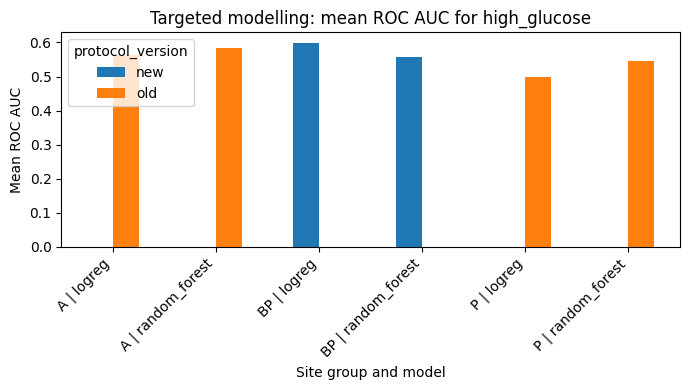

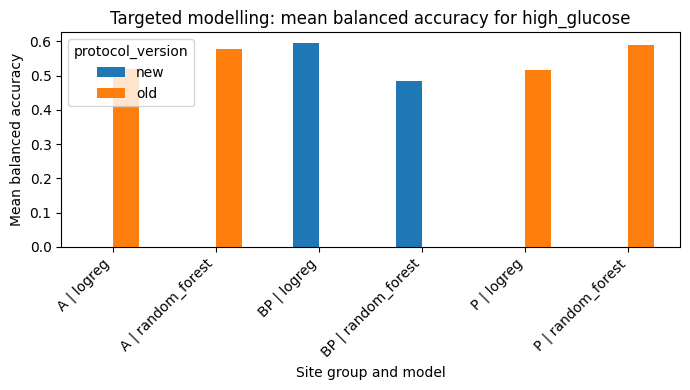

In [258]:
if not targeted_results_df.empty:
    plot_df = targeted_results_df.copy()
    plot_df["label"] = plot_df["site_group"] + " | " + plot_df["model"]

    roc_plot_df = plot_df.pivot(
        index="label",
        columns="protocol_version",
        values="mean_roc_auc",
    )

    ax = roc_plot_df.plot(kind="bar", figsize=(7, 4))
    ax.set_title("Targeted modelling: mean ROC AUC for high_glucose")
    ax.set_xlabel("Site group and model")
    ax.set_ylabel("Mean ROC AUC")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    ba_plot_df = plot_df.pivot(
        index="label",
        columns="protocol_version",
        values="mean_balanced_accuracy",
    )

    ax = ba_plot_df.plot(kind="bar", figsize=(7, 4))
    ax.set_title("Targeted modelling: mean balanced accuracy for high_glucose")
    ax.set_xlabel("Site group and model")
    ax.set_ylabel("Mean balanced accuracy")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()